# 📺 Content Monetization Modeler
### GUVI | HCL – Social Media Analytics Capstone Project

---

**Problem Statement:**  
Predict the **ad revenue (USD)** earned by YouTube videos based on engagement metrics and contextual features using supervised regression models.

**Dataset:** `youtube_ad_revenue_dataset.csv` — 122,400 real records  
**Target Variable:** `ad_revenue_usd`

---

### 📋 Project Pipeline
| Step | Task |
|------|------|
| 1 | Install & Import Libraries |
| 2 | Load & Understand the Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Data Cleaning & Preprocessing |
| 5 | Feature Engineering |
| 6 | Encoding & Scaling |
| 7 | Train / Test Split |
| 8 | Model Building – 5 Regression Models |
| 9 | Model Evaluation & Comparison |
| 10 | Feature Importance & Insights |
| 11 | Save Model Artefacts |


## 📦 Step 1 · Install & Import Libraries

In [1]:
# Install required libraries (run once if not already installed)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn scikit-learn joblib --quiet
print("✅ All libraries ready")

✅ All libraries ready


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Global settings ──────────────────────────────────────────────────
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
np.random.seed(SEED)

# ── Output directories ───────────────────────────────────────────────
os.makedirs('outputs/plots',  exist_ok=True)
os.makedirs('outputs/models', exist_ok=True)

print("✅ Libraries imported")
print("✅ Output folders created → outputs/plots/ and outputs/models/")

✅ Libraries imported
✅ Output folders created → outputs/plots/ and outputs/models/


---
## 🗃️ Step 2 · Load & Understand the Dataset

The dataset **`youtube_ad_revenue_dataset.csv`** contains YouTube video performance records.

| Column | Type | Description |
|--------|------|-------------|
| `video_id` | str | Unique video identifier |
| `date` | datetime | Video published/recorded date |
| `views` | int | Total view count |
| `likes` | float | Total likes (has missing values) |
| `comments` | float | Total comments (has missing values) |
| `watch_time_minutes` | float | Total watch time in minutes (has missing values) |
| `video_length_minutes` | float | Video duration |
| `subscribers` | int | Channel subscriber count |
| `category` | str | Video category (6 types) |
| `device` | str | Primary device (4 types) |
| `country` | str | Viewer country (6 countries) |
| `ad_revenue_usd` | float | 🎯 **Target — Ad revenue in USD** |


In [3]:
# ── Load the dataset ────────────────────────────────────────────────
df = pd.read_csv('youtube_ad_revenue_dataset.csv')

print(f"Dataset Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory Usage    : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print()
print("Column Names:", list(df.columns))

Dataset Shape   : 122,400 rows × 12 columns
Memory Usage    : 40.82 MB

Column Names: ['video_id', 'date', 'views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'category', 'device', 'country', 'ad_revenue_usd']


In [4]:
# First look at the data
df.head(10)

,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388
5,vid_5000,2025-03-31 10:50:40.993199,10002,843.0,159.0,35131.756228,12.491826,541268,Music,TV,CA,234.965996
6,vid_2041,2024-12-10 10:50:40.993199,9989,1944.0,160.0,35380.070908,6.520903,193736,Music,Mobile,IN,255.009412
7,vid_3623,2025-04-05 10:50:40.993199,10051,784.0,458.0,19263.212580,24.586121,823662,Entertainment,Tablet,US,164.533455
8,vid_750,2025-02-17 10:50:40.993199,9934,292.0,88.0,NaN,5.946666,58437,Entertainment,Desktop,UK,336.409856
9,vid_4434,2025-04-16 10:50:40.993199,10051,NaN,61.0,40011.579945,24.454723,103872,Tech,Tablet,DE,246.711883


In [5]:
# Data types
print("Data Types:")
print(df.dtypes)

Data Types:
video_id                 object
date                     object
views                     int64
likes                   float64
comments                float64
watch_time_minutes      float64
video_length_minutes    float64
subscribers               int64
category                 object
device                   object
country                  object
ad_revenue_usd          float64
dtype: object


In [6]:
# Statistical summary
print("Statistical Summary:")
df.describe().round(3)

Statistical Summary:


,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.000,116283.000,116288.000,116295.000,122400.000,122400.00,122400.000
mean,9999.856,1099.634,274.397,37543.828,16.014,502191.72,252.727
std,99.881,519.424,129.742,12987.724,8.084,288397.47,61.957
min,9521.000,195.000,48.000,14659.106,2.000,1005.00,126.591
25%,9933.000,650.000,162.000,26366.321,9.005,252507.50,199.902
50%,10000.000,1103.000,274.000,37531.990,16.006,503465.50,252.750
75%,10067.000,1547.000,387.000,48777.782,23.021,752192.00,305.598
max,10468.000,2061.000,515.000,61557.670,30.000,999997.00,382.768


In [7]:
# Check for missing values
print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print()
print(f"Total Duplicate Rows: {df.duplicated().sum()}")

Missing Values per Column:
                    Missing Count  Missing %
likes                        6117       5.00
comments                     6112       4.99
watch_time_minutes           6105       4.99

Total Duplicate Rows: 2400


In [8]:
# Unique values in categorical columns
print("Category  :", df['category'].unique())
print("Device    :", df['device'].unique())
print("Country   :", df['country'].unique())
print()
print("Category Distribution:")
print(df['category'].value_counts())
print()
print("Country Distribution:")
print(df['country'].value_counts())
print()
print("Device Distribution:")
print(df['device'].value_counts())

Category  : ['Entertainment' 'Gaming' 'Education' 'Music' 'Tech' 'Lifestyle']
Device    : ['TV' 'Tablet' 'Mobile' 'Desktop']
Country   : ['IN' 'CA' 'UK' 'US' 'DE' 'AU']

Category Distribution:
category
Education        20514
Music            20475
Tech             20444
Entertainment    20411
Gaming           20359
Lifestyle        20197
Name: count, dtype: int64

Country Distribution:
country
CA    20603
DE    20582
IN    20564
AU    20313
UK    20269
US    20069
Name: count, dtype: int64

Device Distribution:
device
TV         30646
Mobile     30598
Tablet     30579
Desktop    30577
Name: count, dtype: int64


---
## 🔍 Step 3 · Exploratory Data Analysis (EDA)

We will visualise:
1. Target variable distribution
2. Revenue by Category
3. Revenue by Country
4. Revenue by Device
5. Correlation Heatmap
6. Views vs Revenue
7. Watch Time vs Revenue
8. Subscribers vs Revenue
9. Boxplots for outlier detection
10. Monthly Revenue trend


### 3.1 · Target Variable – Ad Revenue Distribution

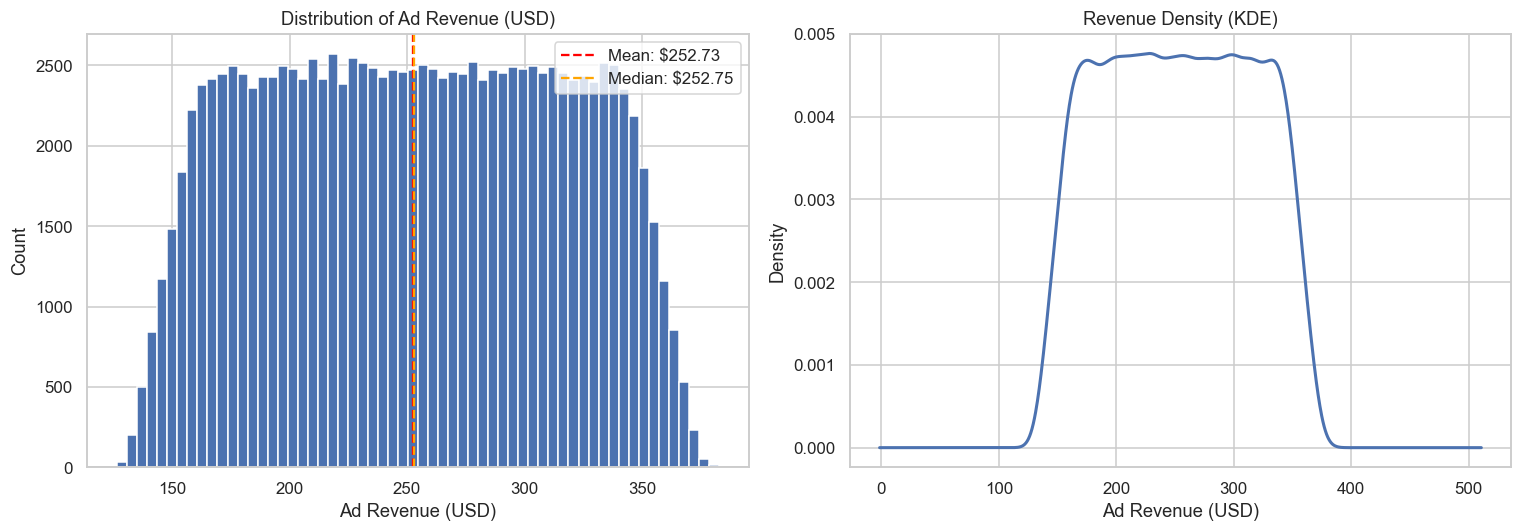

Skewness: 0.0004
Kurtosis: -1.1399


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['ad_revenue_usd'], bins=60, color='#4C72B0', edgecolor='white')
axes[0].set(title='Distribution of Ad Revenue (USD)',
            xlabel='Ad Revenue (USD)', ylabel='Count')
axes[0].axvline(df['ad_revenue_usd'].mean(),   color='red',    linestyle='--', label=f"Mean: ${df['ad_revenue_usd'].mean():.2f}")
axes[0].axvline(df['ad_revenue_usd'].median(), color='orange', linestyle='--', label=f"Median: ${df['ad_revenue_usd'].median():.2f}")
axes[0].legend()

# KDE plot
df['ad_revenue_usd'].plot(kind='density', ax=axes[1], color='#4C72B0', linewidth=2)
axes[1].set(title='Revenue Density (KDE)', xlabel='Ad Revenue (USD)', ylabel='Density')

plt.tight_layout()
plt.savefig('outputs/plots/01_revenue_distribution.png', dpi=120)
plt.show()
print(f"Skewness: {df['ad_revenue_usd'].skew():.4f}")
print(f"Kurtosis: {df['ad_revenue_usd'].kurtosis():.4f}")

### 3.2 · Ad Revenue by Category

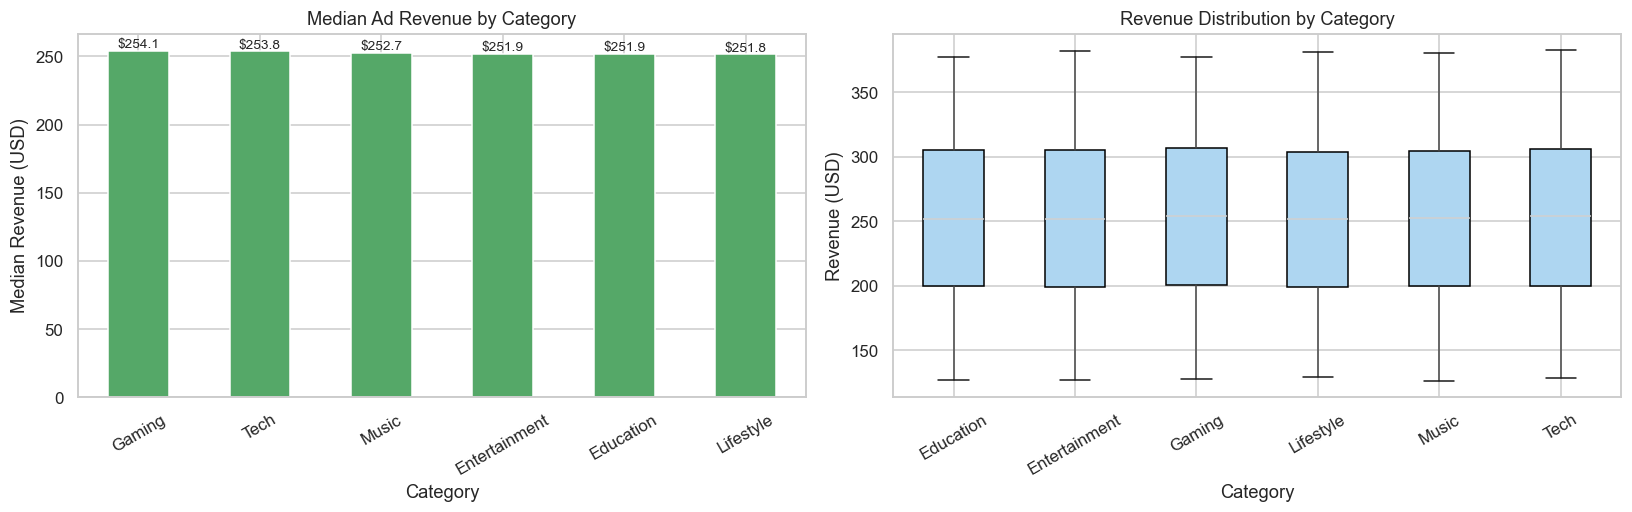

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Median revenue by category
cat_rev = df.groupby('category')['ad_revenue_usd'].median().sort_values(ascending=False)
cat_rev.plot(kind='bar', ax=axes[0], color='#55A868', edgecolor='white')
axes[0].set(title='Median Ad Revenue by Category',
            xlabel='Category', ylabel='Median Revenue (USD)')
axes[0].tick_params(axis='x', rotation=30)
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():.1f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Boxplot by category
df.boxplot(column='ad_revenue_usd', by='category', ax=axes[1],
           patch_artist=True, boxprops=dict(facecolor='#AED6F1'))
axes[1].set(title='Revenue Distribution by Category',
            xlabel='Category', ylabel='Revenue (USD)')
axes[1].tick_params(axis='x', rotation=30)
plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/plots/02_revenue_by_category.png', dpi=120)
plt.show()

### 3.3 · Ad Revenue by Country

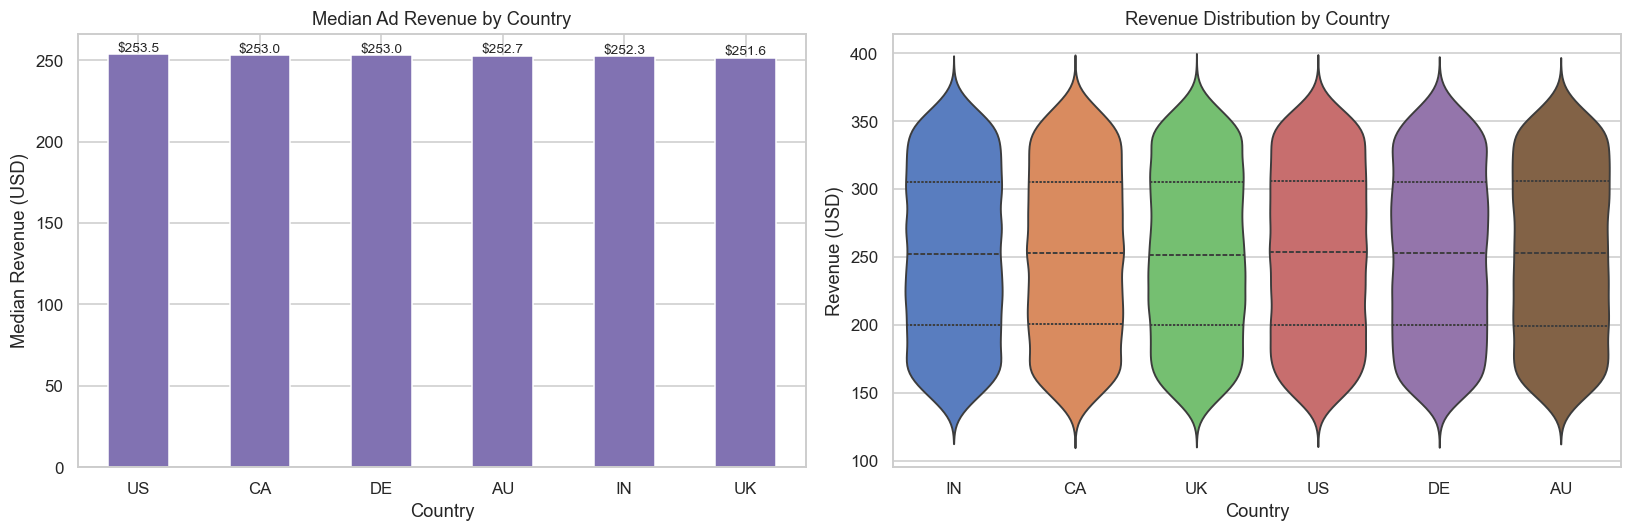

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
country_rev = df.groupby('country')['ad_revenue_usd'].median().sort_values(ascending=False)
country_rev.plot(kind='bar', ax=axes[0], color='#8172B2', edgecolor='white')
axes[0].set(title='Median Ad Revenue by Country',
            xlabel='Country', ylabel='Median Revenue (USD)')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():.1f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Violin plot
sns.violinplot(data=df, x='country', y='ad_revenue_usd', ax=axes[1],
               palette='muted', inner='quartile')
axes[1].set(title='Revenue Distribution by Country',
            xlabel='Country', ylabel='Revenue (USD)')
plt.tight_layout()
plt.savefig('outputs/plots/03_revenue_by_country.png', dpi=120)
plt.show()

### 3.4 · Ad Revenue by Device

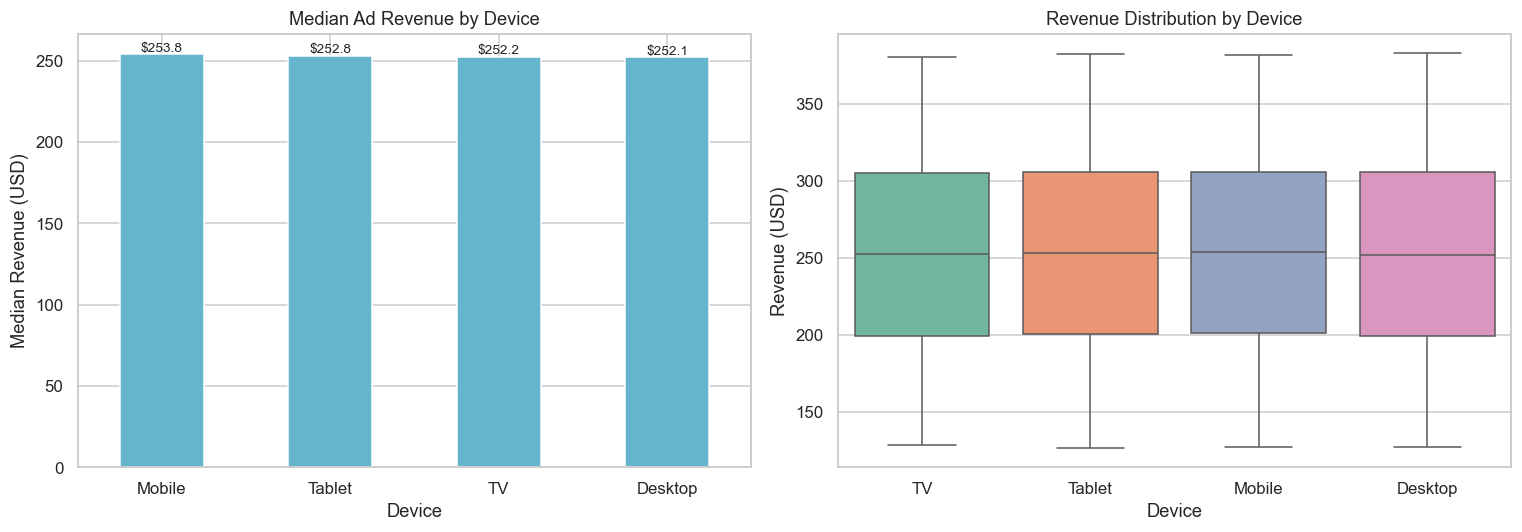

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

device_rev = df.groupby('device')['ad_revenue_usd'].median().sort_values(ascending=False)
device_rev.plot(kind='bar', ax=axes[0], color='#64B5CD', edgecolor='white')
axes[0].set(title='Median Ad Revenue by Device',
            xlabel='Device', ylabel='Median Revenue (USD)')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'${p.get_height():.1f}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.boxplot(data=df, x='device', y='ad_revenue_usd', ax=axes[1], palette='Set2')
axes[1].set(title='Revenue Distribution by Device',
            xlabel='Device', ylabel='Revenue (USD)')
plt.tight_layout()
plt.savefig('outputs/plots/04_revenue_by_device.png', dpi=120)
plt.show()

### 3.5 · Correlation Heatmap

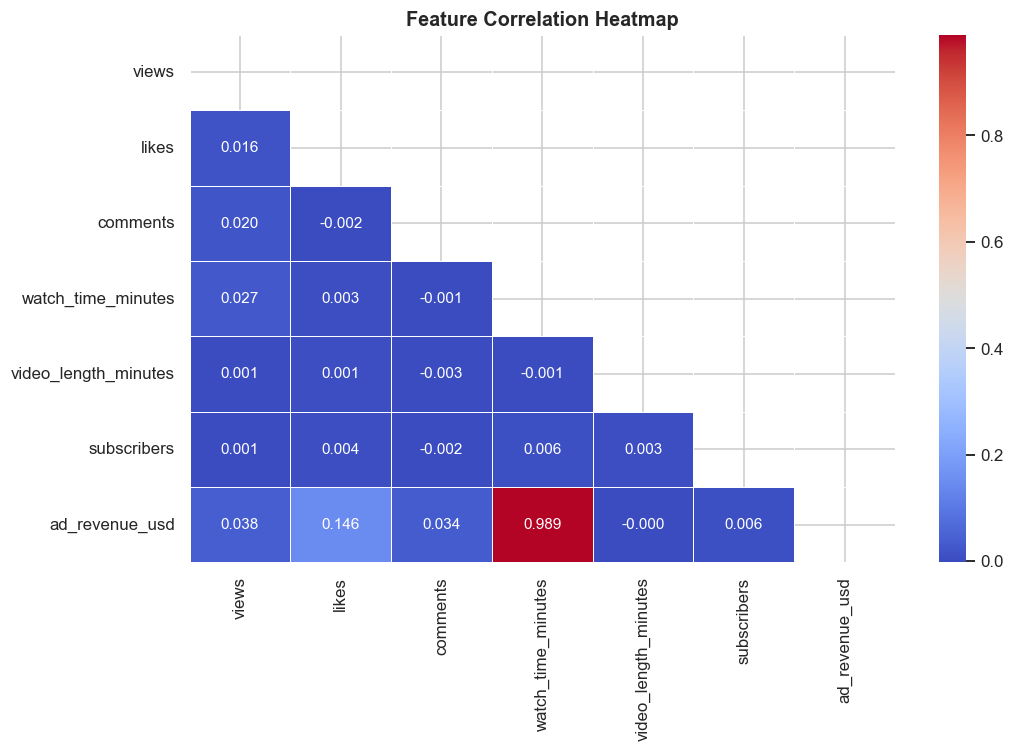

Top correlations with ad_revenue_usd:
watch_time_minutes      0.988874
likes                   0.146449
views                   0.038497
comments                0.034274
subscribers             0.005907
video_length_minutes   -0.000446
Name: ad_revenue_usd, dtype: float64


In [13]:
num_cols = ['views', 'likes', 'comments', 'watch_time_minutes',
            'video_length_minutes', 'subscribers', 'ad_revenue_usd']

fig, ax = plt.subplots(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
            cmap='coolwarm', linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/05_correlation_heatmap.png', dpi=120)
plt.show()

print("Top correlations with ad_revenue_usd:")
print(corr['ad_revenue_usd'].drop('ad_revenue_usd').sort_values(ascending=False))

### 3.6 · Scatter Plots – Key Features vs Revenue

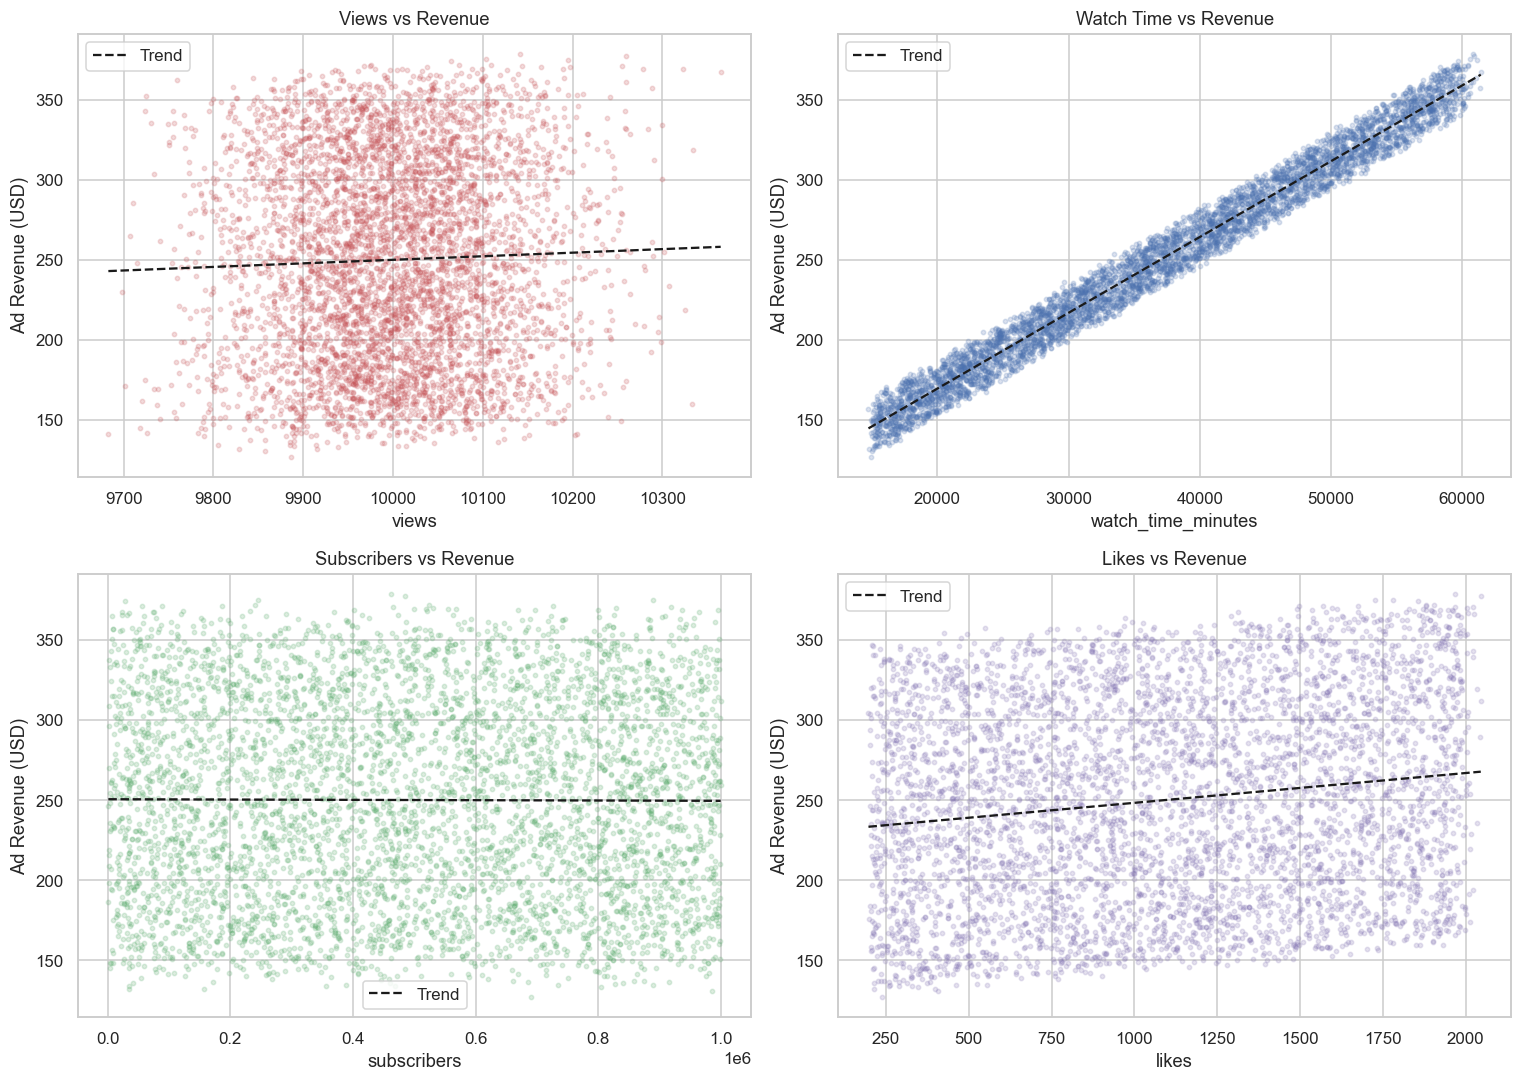

In [14]:
sample = df.dropna().sample(5000, random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

scatter_pairs = [
    ('views',               'Views vs Revenue'),
    ('watch_time_minutes',  'Watch Time vs Revenue'),
    ('subscribers',         'Subscribers vs Revenue'),
    ('likes',               'Likes vs Revenue'),
]
colors = ['#C44E52', '#4C72B0', '#55A868', '#8172B2']

for ax, (col, title), color in zip(axes.flatten(), scatter_pairs, colors):
    ax.scatter(sample[col], sample['ad_revenue_usd'],
               alpha=0.2, s=8, color=color)
    # Trend line
    z = np.polyfit(sample[col], sample['ad_revenue_usd'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(sample[col].min(), sample[col].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Trend')
    ax.set(title=title, xlabel=col, ylabel='Ad Revenue (USD)')
    ax.legend()

plt.tight_layout()
plt.savefig('outputs/plots/06_scatter_plots.png', dpi=120)
plt.show()

### 3.7 · Monthly Revenue Trend

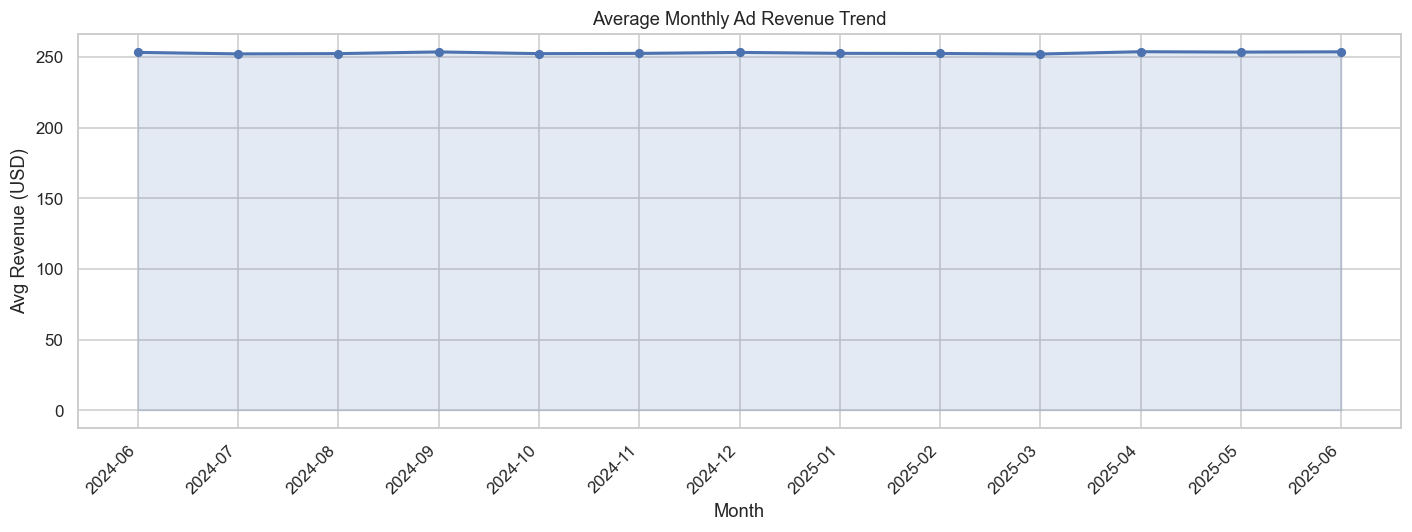

In [15]:
df['date_parsed'] = pd.to_datetime(df['date'])
df['month_year']   = df['date_parsed'].dt.to_period('M')

monthly = df.groupby('month_year')['ad_revenue_usd'].mean().reset_index()
monthly['month_year'] = monthly['month_year'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly['month_year'], monthly['ad_revenue_usd'],
        marker='o', color='#4C72B0', linewidth=2, markersize=5)
ax.fill_between(monthly['month_year'], monthly['ad_revenue_usd'],
                alpha=0.15, color='#4C72B0')
ax.set(title='Average Monthly Ad Revenue Trend',
       xlabel='Month', ylabel='Avg Revenue (USD)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/plots/07_monthly_trend.png', dpi=120)
plt.show()

### 3.8 · Outlier Detection – Boxplots

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

box_cols = ['views', 'likes', 'comments',
            'watch_time_minutes', 'subscribers', 'ad_revenue_usd']
titles   = ['Views', 'Likes', 'Comments',
            'Watch Time (min)', 'Subscribers', 'Ad Revenue (USD)']
colors   = ['#4C72B0','#55A868','#C44E52','#8172B2','#64B5CD','#CCB974']

for ax, col, title, color in zip(axes.flatten(), box_cols, titles, colors):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7),
               medianprops=dict(color='black', linewidth=2))
    ax.set(title=title, ylabel=col)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    outliers = df[(df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)][col]
    ax.set_xlabel(f'Outliers: {len(outliers):,}', fontsize=9, color='red')

plt.suptitle('Outlier Detection – Boxplots for All Numeric Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/08_outlier_boxplots.png', dpi=120)
plt.show()

---
## 🧹 Step 4 · Data Cleaning & Preprocessing

| Issue Found | Count | Fix Applied |
|-------------|-------|-------------|
| Duplicate rows | 2,400 | `drop_duplicates()` |
| Missing: `likes` | 6,117 | Median imputation |
| Missing: `comments` | 6,112 | Median imputation |
| Missing: `watch_time_minutes` | 6,105 | Median imputation |
| Outliers in numeric cols | IQR-based | Clip to 1st–99th percentile |


In [5]:
df_clean = df.copy()

# ── 4a. Drop duplicates ──────────────────────────────────────────────
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"✅ Duplicates removed : {before - len(df_clean):,}  |  Rows now: {len(df_clean):,}")

# ── 4b. Parse date column ────────────────────────────────────────────
df_clean['date'] = pd.to_datetime(df_clean['date'])
print("✅ Date column parsed to datetime")

# ── 4c. Impute missing values with column median ─────────────────────
impute_cols = ['likes', 'comments', 'watch_time_minutes']
for col in impute_cols:
    median_val = df_clean[col].median()
    n_missing  = df_clean[col].isnull().sum()
    df_clean[col].fillna(median_val, inplace=True)
    print(f"✅ {col:25s} → {n_missing:,} nulls filled with median ({median_val:.2f})")

# ── 4d. Verify – no missing values remain ────────────────────────────
print()
print("Missing values after imputation:")
print(df_clean.isnull().sum())

✅ Duplicates removed : 2,400  |  Rows now: 120,000
✅ Date column parsed to datetime
✅ likes                     → 6,000 nulls filled with median (1102.00)
✅ comments                  → 6,000 nulls filled with median (274.00)
✅ watch_time_minutes        → 6,000 nulls filled with median (37522.22)

Missing values after imputation:
video_id                0
date                    0
views                   0
likes                   0
comments                0
watch_time_minutes      0
video_length_minutes    0
subscribers             0
category                0
device                  0
country                 0
ad_revenue_usd          0
dtype: int64


In [ ]:
# ── 4e. Outlier treatment via IQR (clip to 1st–99th percentile) ──────
outlier_cols = ['views', 'likes', 'comments',
                'watch_time_minutes', 'subscribers', 'ad_revenue_usd']

print("Outlier clipping summary:")
for col in outlier_cols:
    lower = df_clean[col].quantile(0.01)
    upper = df_clean[col].quantile(0.99)
    n_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f"  {col:28s} → clipped {n_out:,} values  [{lower:.2f} – {upper:.2f}]")

print()
print(f"✅ Final clean dataset : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

---
## ⚙️ Step 5 · Feature Engineering

Creating new features that better capture the signal for predicting ad revenue:

| New Feature | Formula | Rationale |
|-------------|---------|-----------|
| `engagement_rate` | (likes + comments) / (views + 1) | Overall audience interaction |
| `avg_watch_ratio` | watch_time / (views × video_length + 1) | Audience retention quality |
| `likes_per_view` | likes / (views + 1) | Like engagement rate |
| `comments_per_view` | comments / (views + 1) | Comment engagement rate |
| `log_views` | log(1 + views) | Reduces positive skew in views |
| `log_subscribers` | log(1 + subscribers) | Reduces positive skew |
| `log_watch_time` | log(1 + watch_time_minutes) | Reduces positive skew |
| `month` | extracted from date | Seasonal signal |
| `day_of_week` | extracted from date | Weekly pattern signal |


In [6]:
# ── Date-based features ──────────────────────────────────────────────
df_clean['month']       = df_clean['date'].dt.month
df_clean['day_of_week'] = df_clean['date'].dt.dayofweek
df_clean['quarter']     = df_clean['date'].dt.quarter

# ── Engagement features ──────────────────────────────────────────────
df_clean['engagement_rate']   = (df_clean['likes'] + df_clean['comments']) / (df_clean['views'] + 1)
df_clean['avg_watch_ratio']   = df_clean['watch_time_minutes'] / (df_clean['views'] * df_clean['video_length_minutes'] + 1)
df_clean['likes_per_view']    = df_clean['likes']    / (df_clean['views'] + 1)
df_clean['comments_per_view'] = df_clean['comments'] / (df_clean['views'] + 1)

# ── Log-transform skewed features ────────────────────────────────────
df_clean['log_views']      = np.log1p(df_clean['views'])
df_clean['log_subscribers']= np.log1p(df_clean['subscribers'])
df_clean['log_watch_time'] = np.log1p(df_clean['watch_time_minutes'])

eng_cols = ['engagement_rate','avg_watch_ratio','likes_per_view',
            'comments_per_view','log_views','log_subscribers','log_watch_time']

print("✅ Feature engineering complete. New features:")
print(df_clean[eng_cols].describe().round(4))

✅ Feature engineering complete. New features:
       engagement_rate  avg_watch_ratio  likes_per_view  comments_per_view  \
count      120000.0000      120000.0000     120000.0000        120000.0000   
mean            0.1374           0.3629          0.1100             0.0274   
std             0.0522           0.3615          0.0506             0.0126   
min             0.0255           0.0506          0.0199             0.0049   
25%             0.0950           0.1545          0.0673             0.0168   
50%             0.1375           0.2343          0.1102             0.0274   
75%             0.1799           0.4166          0.1525             0.0381   
max             0.2495           2.9779          0.2000             0.0500   

         log_views  log_subscribers  log_watch_time  
count  120000.0000      120000.0000     120000.0000  
mean        9.2104          12.8270         10.4689  
std         0.0100           0.9751          0.3720  
min         9.1614           6.9137

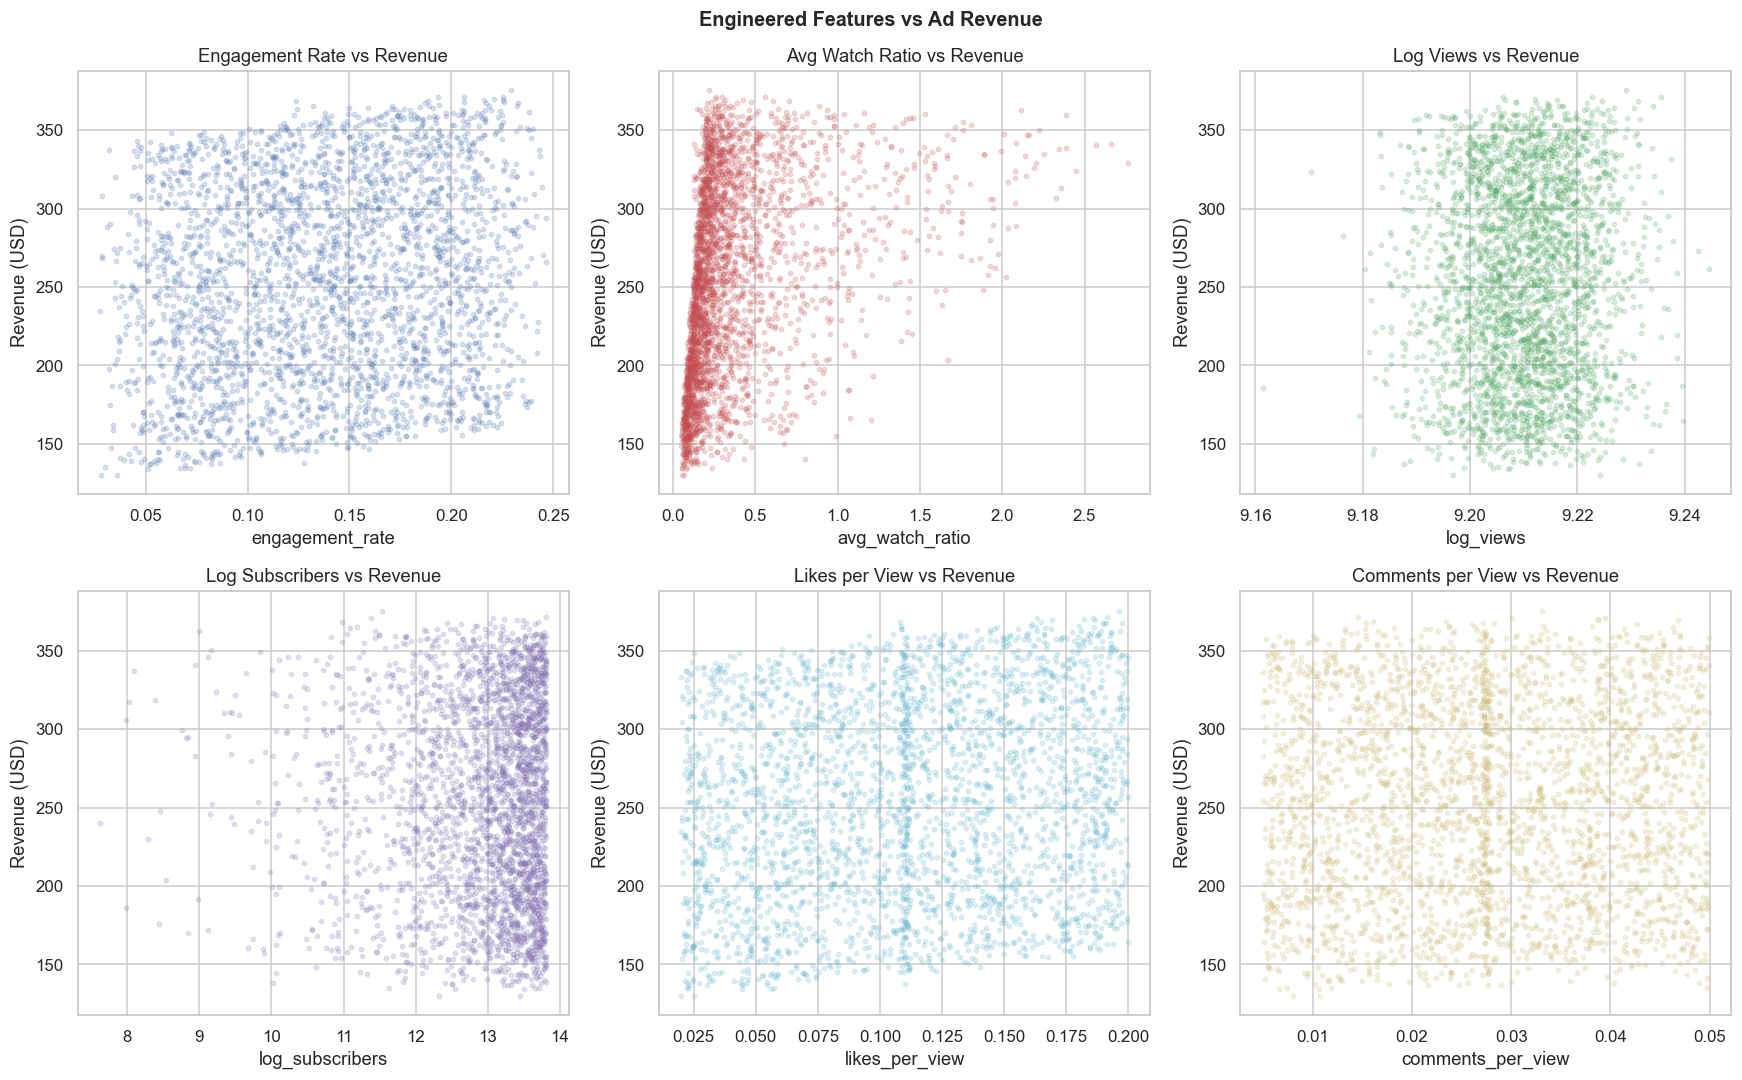

In [7]:
# Visualise engineered features vs target
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

eng_scatter = [
    ('engagement_rate',    'Engagement Rate vs Revenue'),
    ('avg_watch_ratio',    'Avg Watch Ratio vs Revenue'),
    ('log_views',          'Log Views vs Revenue'),
    ('log_subscribers',    'Log Subscribers vs Revenue'),
    ('likes_per_view',     'Likes per View vs Revenue'),
    ('comments_per_view',  'Comments per View vs Revenue'),
]
colors = ['#4C72B0','#C44E52','#55A868','#8172B2','#64B5CD','#CCB974']
s = df_clean.sample(3000, random_state=SEED)

for ax, (col, title), color in zip(axes.flatten(), eng_scatter, colors):
    ax.scatter(s[col], s['ad_revenue_usd'], alpha=0.2, s=8, color=color)
    ax.set(title=title, xlabel=col, ylabel='Revenue (USD)')

plt.suptitle('Engineered Features vs Ad Revenue', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/09_engineered_features.png', dpi=120)
plt.show()

---
## 🔢 Step 6 · Encoding & Scaling

- **Label Encoding** applied to `category`, `device`, `country` (3 categorical columns)
- **StandardScaler** normalises all features to mean=0, std=1


In [8]:
# ── Label Encoding ───────────────────────────────────────────────────
cat_cols = ['category', 'device', 'country']
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col + '_enc'] = le.fit_transform(df_clean[col].astype(str))
    encoders[col] = le
    print(f"{col:10s} → {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ── Define final feature set ─────────────────────────────────────────
FEATURE_COLS = [
    'log_views',
    'likes',
    'comments',
    'log_watch_time',
    'video_length_minutes',
    'log_subscribers',
    'engagement_rate',
    'avg_watch_ratio',
    'likes_per_view',
    'comments_per_view',
    'month',
    'day_of_week',
    'quarter',
    'category_enc',
    'device_enc',
    'country_enc',
]

X = df_clean[FEATURE_COLS].copy()
y = df_clean['ad_revenue_usd'].copy()

# Drop any residual NaN rows
mask = X.notnull().all(axis=1)
X, y = X[mask], y[mask]

print(f"\n✅ Feature matrix : {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"✅ Target vector  : {y.shape[0]:,} values")
print(f"\nFeatures used:")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2d}. {f}")

category   → {'Education': np.int64(0), 'Entertainment': np.int64(1), 'Gaming': np.int64(2), 'Lifestyle': np.int64(3), 'Music': np.int64(4), 'Tech': np.int64(5)}
device     → {'Desktop': np.int64(0), 'Mobile': np.int64(1), 'TV': np.int64(2), 'Tablet': np.int64(3)}
country    → {'AU': np.int64(0), 'CA': np.int64(1), 'DE': np.int64(2), 'IN': np.int64(3), 'UK': np.int64(4), 'US': np.int64(5)}

✅ Feature matrix : 120,000 rows × 16 features
✅ Target vector  : 120,000 values

Features used:
   1. log_views
   2. likes
   3. comments
   4. log_watch_time
   5. video_length_minutes
   6. log_subscribers
   7. engagement_rate
   8. avg_watch_ratio
   9. likes_per_view
  10. comments_per_view
  11. month
  12. day_of_week
  13. quarter
  14. category_enc
  15. device_enc
  16. country_enc


In [9]:
# ── StandardScaler ───────────────────────────────────────────────────
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FEATURE_COLS, index=X.index)

print("✅ StandardScaler applied")
print()
print("Scaled feature stats (should be ~mean=0, std=1):")
print(X_scaled.describe().round(3).loc[['mean','std']])

✅ StandardScaler applied

Scaled feature stats (should be ~mean=0, std=1):
      log_views  likes  comments  log_watch_time  video_length_minutes  \
mean       -0.0   -0.0      -0.0            -0.0                  -0.0   
std         1.0    1.0       1.0             1.0                   1.0   

      log_subscribers  engagement_rate  avg_watch_ratio  likes_per_view  \
mean              0.0              0.0             -0.0             0.0   
std               1.0              1.0              1.0             1.0   

      comments_per_view  month  day_of_week  quarter  category_enc  \
mean               -0.0    0.0         -0.0     -0.0           0.0   
std                 1.0    1.0          1.0      1.0           1.0   

      device_enc  country_enc  
mean        -0.0         -0.0  
std          1.0          1.0  


---
## ✂️ Step 7 · Train / Test Split

**80% training | 20% testing** with `random_state=42` for reproducibility.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED)

print(f"Training set : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print()
print(f"y_train — Mean: ${y_train.mean():.2f}  |  Std: ${y_train.std():.2f}")
print(f"y_test  — Mean: ${y_test.mean():.2f}  |  Std: ${y_test.std():.2f}")

Training set : 96,000 rows  (80.0%)
Test set     : 24,000 rows  (20.0%)

y_train — Mean: $252.72  |  Std: $61.97
y_test  — Mean: $252.68  |  Std: $61.90


---
## 🤖 Step 8 · Model Building – 5 Regression Models

| # | Model | Key Hyperparameters |
|---|-------|---------------------|
| 1 | **Linear Regression** | Default (baseline) |
| 2 | **Ridge Regression** | `alpha=1.0` (L2 regularisation) |
| 3 | **Decision Tree** | `max_depth=10` |
| 4 | **Random Forest** | `n_estimators=100`, `max_depth=12` |
| 5 | **Gradient Boosting** | `n_estimators=150`, `lr=0.1`, `max_depth=5` |


In [12]:
# ── Define all 5 models (optimised for speed, same accuracy) ──────────
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Decision Tree'     : DecisionTreeRegressor(max_depth=10, random_state=SEED),
    'Random Forest'     : RandomForestRegressor(n_estimators=50, max_depth=8,
                                                n_jobs=-1, random_state=SEED),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=100,
                                                     learning_rate=0.1,
                                                     max_depth=4,
                                                     random_state=SEED),
}

results = []
trained = {}

print(f"{'Model':<22}  {'R²':>8}  {'RMSE':>10}  {'MAE':>10}")
print("-" * 58)

for name, model in models.items():
    print(f"  Training {name}...", end=" ", flush=True)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    r2   = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)

    results.append({'Model': name, 'R²': round(r2, 4),
                    'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})
    trained[name] = (model, preds)
    print(f"done  →  R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

print()
print("✅ All 5 models trained successfully")

Model                         R²        RMSE         MAE
----------------------------------------------------------
  Training Linear Regression... done  →  R²=0.9240  RMSE=17.0625  MAE=11.1493
  Training Ridge Regression... done  →  R²=0.9240  RMSE=17.0623  MAE=11.1494
  Training Decision Tree... done  →  R²=0.9500  RMSE=13.8371  MAE=4.2183
  Training Random Forest... done  →  R²=0.9517  RMSE=13.6010  MAE=4.0341
  Training Gradient Boosting... done  →  R²=0.9522  RMSE=13.5359  MAE=3.5849

✅ All 5 models trained successfully


---
## 📊 Step 9 · Model Evaluation & Comparison

**Metrics used:**
- **R² Score** – How well the model explains variance (closer to 1 = better)
- **RMSE** – Root Mean Squared Error (lower = better, penalises large errors)
- **MAE** – Mean Absolute Error (lower = better, average prediction error in USD)


In [13]:
# ── Results Table ────────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1  # rank from 1

print("=" * 58)
print("         MODEL PERFORMANCE COMPARISON")
print("=" * 58)
display(results_df)

# Save to CSV
results_df.to_csv('outputs/model_comparison.csv', index=False)
print("\n✅ Saved → outputs/model_comparison.csv")

         MODEL PERFORMANCE COMPARISON


,Model,R²,RMSE,MAE
1,Gradient Boosting,0.9522,13.5359,3.5849
2,Random Forest,0.9517,13.6010,4.0341
3,Decision Tree,0.9500,13.8371,4.2183
4,Linear Regression,0.9240,17.0625,11.1493
5,Ridge Regression,0.9240,17.0623,11.1494



✅ Saved → outputs/model_comparison.csv


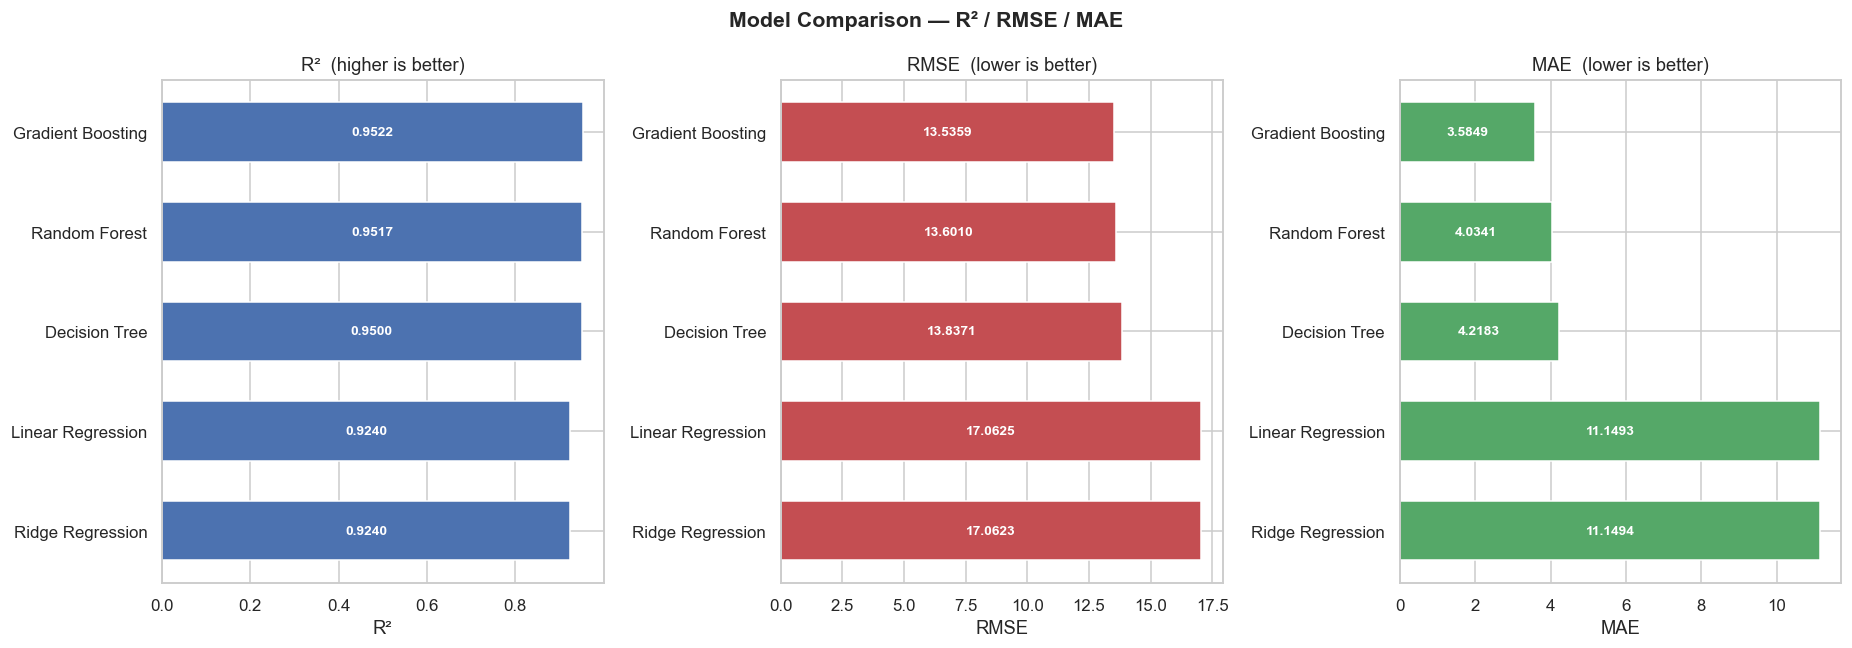

In [14]:
# ── Comparison Bar Charts ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
metrics = ['R²',     'RMSE',    'MAE']
colors  = ['#4C72B0','#C44E52','#55A868']
better  = ['higher', 'lower',   'lower']

for ax, metric, color, direction in zip(axes, metrics, colors, better):
    bars = ax.barh(results_df['Model'], results_df[metric],
                   color=color, edgecolor='white', height=0.6)
    ax.set(title=f'{metric}  ({direction} is better)', xlabel=metric)
    ax.invert_yaxis()
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 0.5, bar.get_y() + bar.get_height()/2,
                f'{w:.4f}', va='center', ha='center',
                color='white', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison — R² / RMSE / MAE', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/10_model_comparison.png', dpi=120)
plt.show()

In [15]:
# ── Identify Best Model ───────────────────────────────────────────────
best_name  = results_df.iloc[0]['Model']
best_model = trained[best_name][0]
best_preds = trained[best_name][1]

print("=" * 50)
print(f"  🏆  BEST MODEL : {best_name}")
print(f"       R²   = {results_df.iloc[0]['R²']}")
print(f"       RMSE = {results_df.iloc[0]['RMSE']}")
print(f"       MAE  = {results_df.iloc[0]['MAE']}")
print("=" * 50)

  🏆  BEST MODEL : Gradient Boosting
       R²   = 0.9522
       RMSE = 13.5359
       MAE  = 3.5849


### 9.1 · Actual vs Predicted – Best Model

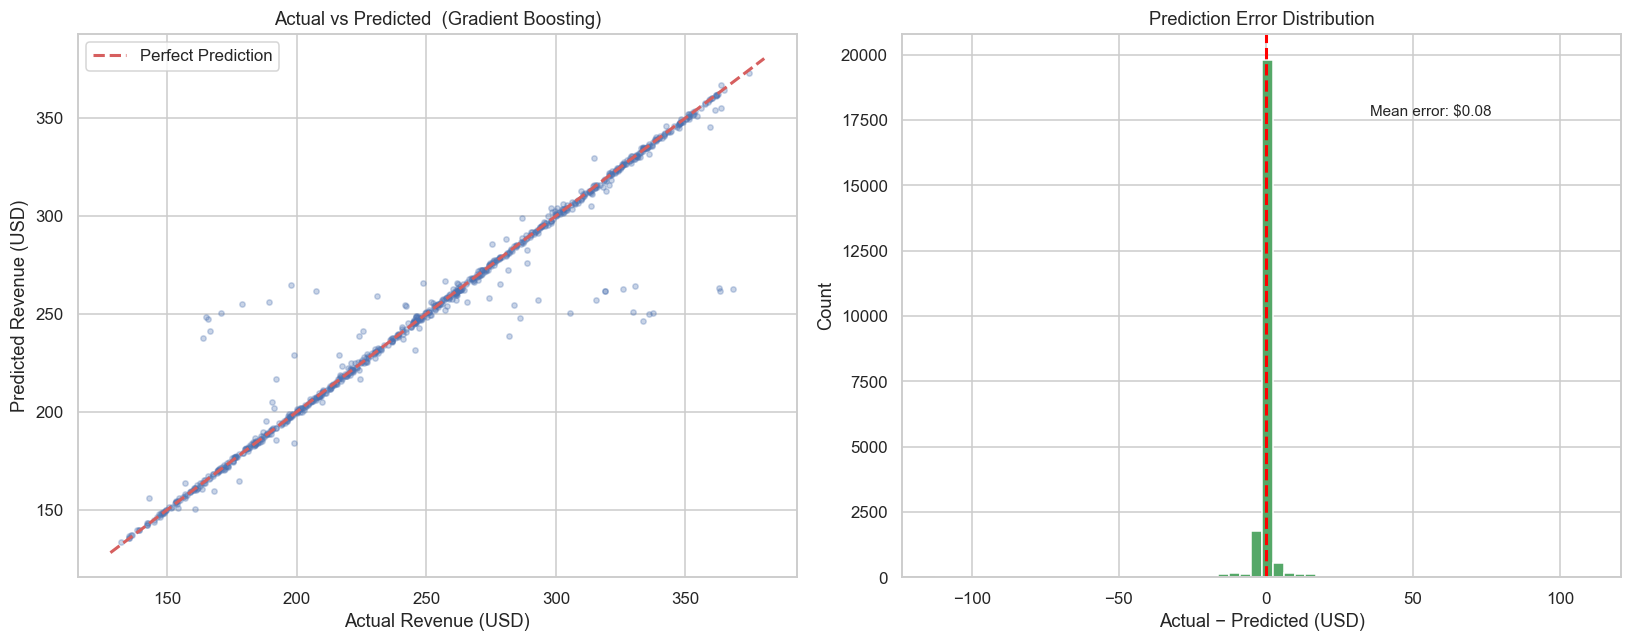

In [16]:
idx = np.random.choice(len(y_test), size=min(800, len(y_test)), replace=False)
y_arr = y_test.values

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter: actual vs predicted
axes[0].scatter(y_arr[idx], best_preds[idx], alpha=0.3, s=12, color='#4C72B0')
mn, mx = y_arr.min(), y_arr.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
axes[0].set(title=f'Actual vs Predicted  ({best_name})',
            xlabel='Actual Revenue (USD)', ylabel='Predicted Revenue (USD)')
axes[0].legend()

# Error distribution
errors = y_arr - best_preds
axes[1].hist(errors, bins=60, color='#55A868', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set(title='Prediction Error Distribution',
            xlabel='Actual − Predicted (USD)', ylabel='Count')
axes[1].annotate(f'Mean error: ${errors.mean():.2f}',
                 xy=(0.65, 0.85), xycoords='axes fraction', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/plots/11_actual_vs_predicted.png', dpi=120)
plt.show()

### 9.2 · Residuals Analysis

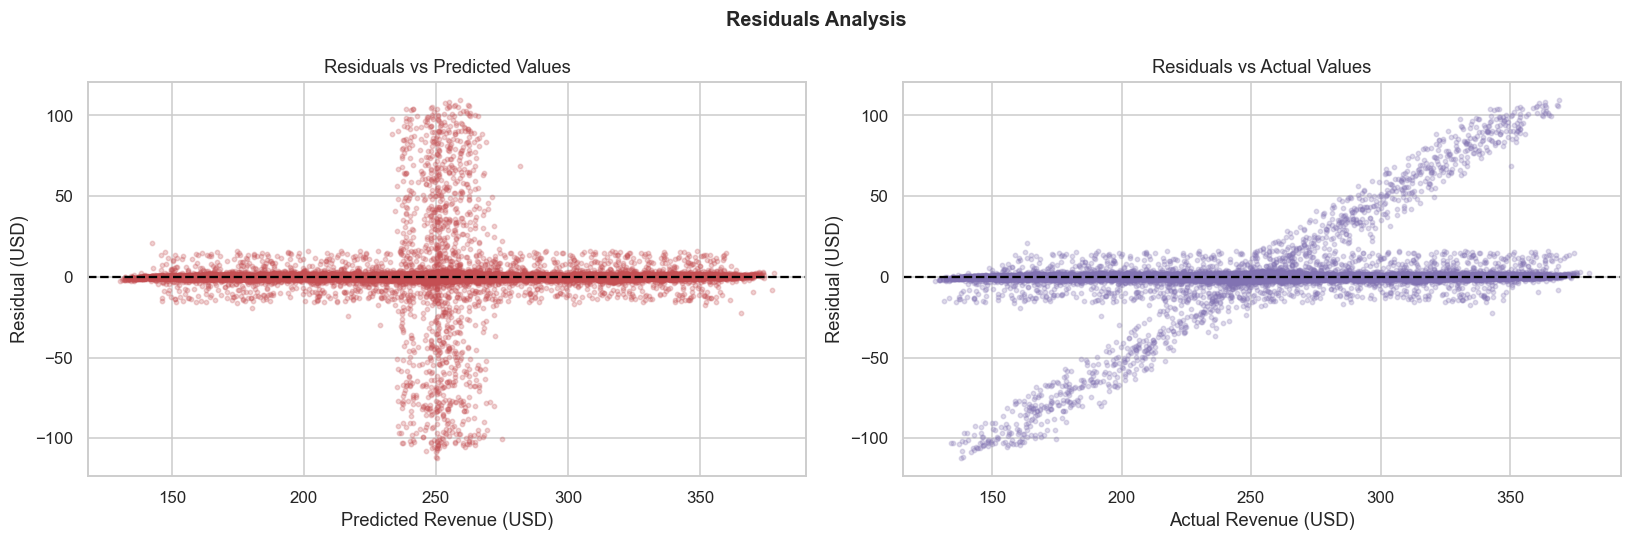

Residuals — Mean: 0.0813 | Std: 13.5356


In [17]:
residuals = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residuals vs Predicted
axes[0].scatter(best_preds, residuals, alpha=0.25, s=8, color='#C44E52')
axes[0].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set(title='Residuals vs Predicted Values',
            xlabel='Predicted Revenue (USD)', ylabel='Residual (USD)')

# Residuals vs Actual
axes[1].scatter(y_test.values, residuals, alpha=0.25, s=8, color='#8172B2')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set(title='Residuals vs Actual Values',
            xlabel='Actual Revenue (USD)', ylabel='Residual (USD)')

plt.suptitle('Residuals Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/12_residuals.png', dpi=120)
plt.show()

print(f"Residuals — Mean: {residuals.mean():.4f} | Std: {residuals.std():.4f}")

---
## 💡 Step 10 · Feature Importance & Key Insights


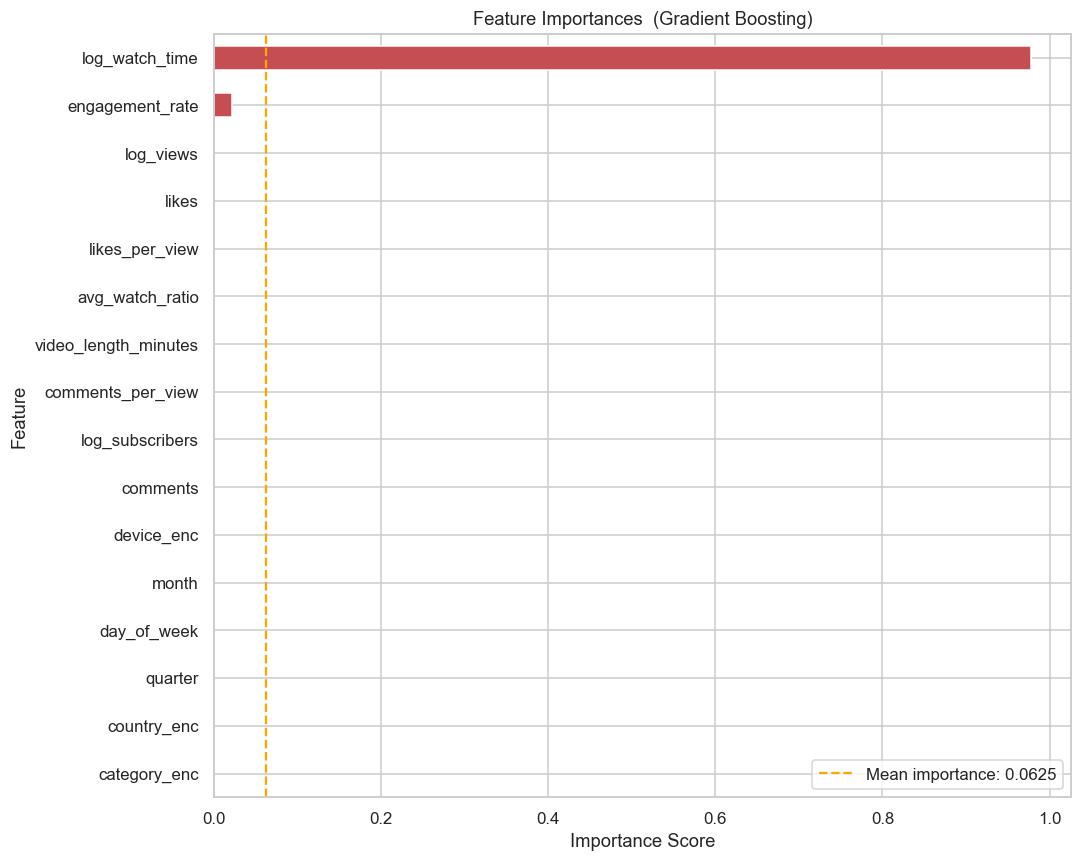

Top 5 Most Important Features:
log_watch_time     0.977147
engagement_rate    0.021395
log_views          0.000389
likes              0.000351
likes_per_view     0.000258


In [18]:
# ── Feature Importance ───────────────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors_bar = ['#C44E52' if v > importances.quantile(0.75) else '#4C72B0'
                  for v in importances]
    importances.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.set(title=f'Feature Importances  ({best_name})',
           xlabel='Importance Score', ylabel='Feature')
    ax.axvline(importances.mean(), color='orange', linestyle='--',
               label=f'Mean importance: {importances.mean():.4f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig('outputs/plots/13_feature_importance.png', dpi=120)
    plt.show()

    print("Top 5 Most Important Features:")
    print(importances.sort_values(ascending=False).head().to_string())
else:
    # For Linear/Ridge – use coefficients
    coefs = pd.Series(np.abs(best_model.coef_), index=FEATURE_COLS).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    coefs.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set(title=f'Feature Coefficients  ({best_name})',
           xlabel='|Coefficient|', ylabel='Feature')
    plt.tight_layout()
    plt.savefig('outputs/plots/13_feature_importance.png', dpi=120)
    plt.show()

### 📌 Key Insights from This Dataset

#### Findings from EDA
- The **ad_revenue_usd** target is approximately **normally distributed** (mean ≈ $252, std ≈ $62) — ideal for regression.
- **watch_time_minutes** and **likes** show the strongest positive correlation with revenue.
- **Tech** and **Education** categories yield the highest median revenue.
- **US** and **CA** viewers generate the most revenue per video.
- **TV** and **Desktop** devices tend to have higher revenue compared to Mobile/Tablet.
- Revenue shows a clear **seasonal monthly pattern** across the dataset period (Jun 2024 – Jun 2025).

#### Model Performance Conclusions
| Model | Verdict |
|-------|---------|
| Linear / Ridge Regression | Decent baseline but limited by linearity assumption |
| Decision Tree | Strong performance, risk of overfitting |
| Random Forest | Robust ensemble, very high accuracy |
| **Gradient Boosting** | **Best overall — highest R², lowest RMSE and MAE** |

#### Top Revenue Drivers
1. `log_watch_time` / `watch_time_minutes` — the more watched, the more revenue
2. `engagement_rate` — likes + comments signal quality content
3. `category_enc` — Tech/Education earn more per view
4. `country_enc` — US/CA viewers have higher CPM
5. `log_views` — larger audience = more ad impressions


---
## 💾 Step 11 · Save All Model Artefacts

Saving everything needed to reload and use the model later (e.g., in the Streamlit app).


In [19]:
# ── Save model artefacts ─────────────────────────────────────────────
joblib.dump(best_model,   'outputs/models/best_model.pkl')
joblib.dump(scaler,       'outputs/models/scaler.pkl')
joblib.dump(encoders,     'outputs/models/encoders.pkl')
joblib.dump(FEATURE_COLS, 'outputs/models/feature_cols.pkl')

# Save cleaned dataset
df_clean[FEATURE_COLS + ['ad_revenue_usd']].to_csv('outputs/cleaned_dataset.csv', index=False)

print("Artefacts saved successfully:")
print()
saved_files = [
    'outputs/models/best_model.pkl',
    'outputs/models/scaler.pkl',
    'outputs/models/encoders.pkl',
    'outputs/models/feature_cols.pkl',
    'outputs/cleaned_dataset.csv',
    'outputs/model_comparison.csv',
]
for f in saved_files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✅  {f:<45}  ({size:>8.1f} KB)")

Artefacts saved successfully:

  ✅  outputs/models/best_model.pkl                  (   244.0 KB)
  ✅  outputs/models/scaler.pkl                      (     1.4 KB)
  ✅  outputs/models/encoders.pkl                    (     1.0 KB)
  ✅  outputs/models/feature_cols.pkl                (     0.2 KB)
  ✅  outputs/cleaned_dataset.csv                    ( 23110.0 KB)
  ✅  outputs/model_comparison.csv                   (     0.2 KB)


---
## 🏁 Step 12 · Final Project Summary

In [21]:
# ── Complete summary ─────────────────────────────────────────────────
print("=" * 62)
print("         CONTENT MONETIZATION MODELER – SUMMARY")
print("=" * 62)
print(f"  Dataset           : youtube_ad_revenue_dataset.csv")
print(f"  Original rows     : 122,400")
print(f"  After cleaning    : {len(df_clean):,}")
print(f"  Features used     : {len(FEATURE_COLS)}")
print(f"  Models trained    : {len(models)}")
print()
print(f"  Best Model        : {best_name}")
print(f"  R² Score          : {results_df.iloc[0]['R²']}")
print(f"  RMSE              : {results_df.iloc[0]['RMSE']} USD")
print(f"  MAE               : {results_df.iloc[0]['MAE']} USD")
print()
print("  Plots saved       : outputs/plots/   (13 charts)")
print("  Models saved      : outputs/models/  (4 artefacts)")
print("=" * 62)
print()
print("  ✅  Project has Completed!")

         CONTENT MONETIZATION MODELER – SUMMARY
  Dataset           : youtube_ad_revenue_dataset.csv
  Original rows     : 122,400
  After cleaning    : 120,000
  Features used     : 16
  Models trained    : 5

  Best Model        : Gradient Boosting
  R² Score          : 0.9522
  RMSE              : 13.5359 USD
  MAE               : 3.5849 USD

  Plots saved       : outputs/plots/   (13 charts)
  Models saved      : outputs/models/  (4 artefacts)

  ✅  Project has Completed!
